In [1]:
import torch

In [2]:
### Select device (GPU) ###

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'

print('Selected device:', device)

Selected device: cuda


In [3]:
import pandas as pd

### Reading data set ###

df = pd.read_csv('../data-sets/eng-nld.txt', sep='\t', header=None, usecols=[0, 1], names=['ENG', 'NLD'], dtype='string')
df.dropna()

print(df.info())
print()
print(df.sample())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76224 entries, 0 to 76223
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ENG     76224 non-null  string
 1   NLD     76224 non-null  string
dtypes: string(2)
memory usage: 1.2 MB
None

                                                 ENG  \
70476  Tom is afraid that he's going to look stupid.   

                                           NLD  
70476  Tom is bang dat hij er dom zal uitzien.  


In [4]:
from nltk import word_tokenize

### Preprocessing ###

train_frac = 0.8
max_size = 15

sos_token = "<sos>"
eos_token = "<eos>"


# Tokenize
df['eng_tokens'] = df['ENG'].apply(lambda x: [sos_token] + word_tokenize(x.lower()) + [eos_token])
df['nld_tokens'] = df['NLD'].apply(lambda x: [sos_token] + word_tokenize(x.lower()) + [eos_token])

print('Total rows from file:', len(df))

# Trim
df = df.drop(df[
    (df['eng_tokens'].map(len) > max_size) | 
    (df['nld_tokens'].map(len) > max_size)
].index)

# Split
df = df.sample(frac=1).reset_index(drop=True)
split = int(train_frac * len(df))

train_data = df.iloc[:split, :]
test_data  = df.iloc[split:, :]
test_data.reset_index(drop=True, inplace=True)

print('Total rows of train data::', len(train_data))


train_data

Total rows from file: 76224
Total rows of train data:: 59412


,ENG,NLD,eng_tokens,nld_tokens
0,I just want to talk to you.,Ik wil gewoon met u praten.,"[<sos>, i, just, want, to, talk, to, you, ., <...","[<sos>, ik, wil, gewoon, met, u, praten, ., <e..."
1,You shouldn't drink the tap water here.,Je moet hier geen kraanwater drinken.,"[<sos>, you, should, n't, drink, the, tap, wat...","[<sos>, je, moet, hier, geen, kraanwater, drin..."
2,It seems to me that you were wrong.,Het lijkt me dat je je vergist hebt.,"[<sos>, it, seems, to, me, that, you, were, wr...","[<sos>, het, lijkt, me, dat, je, je, vergist, ..."
3,I'm a doctor.,Ik ben een dokter.,"[<sos>, i, 'm, a, doctor, ., <eos>]","[<sos>, ik, ben, een, dokter, ., <eos>]"
4,I wasn't paying attention.,Ik lette niet op.,"[<sos>, i, was, n't, paying, attention, ., <eos>]","[<sos>, ik, lette, niet, op, ., <eos>]"
...,...,...,...,...
59407,Did they say why?,Hebben ze gezegd waarom?,"[<sos>, did, they, say, why, ?, <eos>]","[<sos>, hebben, ze, gezegd, waarom, ?, <eos>]"
59408,I've read this book before.,Ik heb dit boek vroeger al eens gelezen.,"[<sos>, i, 've, read, this, book, before, ., <...","[<sos>, ik, heb, dit, boek, vroeger, al, eens,..."
59409,Tom has a scar on his cheek.,Tom heeft een litteken op zijn wang.,"[<sos>, tom, has, a, scar, on, his, cheek, ., ...","[<sos>, tom, heeft, een, litteken, op, zijn, w..."
59410,He's offered to help.,Hij heeft aangeboden me te helpen.,"[<sos>, he, 's, offered, to, help, ., <eos>]","[<sos>, hij, heeft, aangeboden, me, te, helpen..."


In [5]:
import torchtext

min_freq  = 2
unk_token = '<unk>'
pad_token = '<pad>'

special_tokens = [unk_token, pad_token, sos_token, eos_token]


eng_vocab = torchtext.vocab.build_vocab_from_iterator(
    train_data['eng_tokens'],
    min_freq=min_freq,
    specials=special_tokens
)


nld_vocab = torchtext.vocab.build_vocab_from_iterator(
    train_data['nld_tokens'],
    min_freq=min_freq,
    specials=special_tokens
)

eng_vocab.set_default_index(eng_vocab[unk_token])
nld_vocab.set_default_index(nld_vocab[unk_token])


print('Unique tokens in \'eng_tokens\' column:', len(eng_vocab))
print('Unique tokens in \'nld_tokens\' column:', len(nld_vocab))

Unique tokens in 'eng_tokens' column: 5906
Unique tokens in 'nld_tokens' column: 7440


In [6]:
import random
import numpy as np

### Vectorize data set ###

eng_pad_index = eng_vocab[pad_token]
nld_pad_index = nld_vocab[pad_token]


def build_dataset(subset):
    X = np.zeros((len(subset), max_size), dtype=np.int32)
    Y = np.zeros((len(subset), max_size), dtype=np.int32)
        
    for ix, row in subset.iterrows():
        eng_ixs = eng_vocab.lookup_indices(row['eng_tokens'])
        eng_ixs = eng_ixs + [eng_pad_index] * (max_size - len(eng_ixs))

        nld_ixs = nld_vocab.lookup_indices(row['nld_tokens'])
        nld_ixs = nld_ixs + [nld_pad_index] * (max_size - len(nld_ixs))

        X[ix] = eng_ixs
        Y[ix] = nld_ixs

    X = torch.tensor(X, dtype=torch.long)
    Y = torch.tensor(Y, dtype=torch.long)

    return X, Y


Xtr, Ytr = build_dataset(train_data)
Xte, Yte = build_dataset(test_data)


print('Xtr shape:', Xtr.shape)
ix = random.randint(0, len(Xtr))
print(eng_vocab.lookup_tokens(Xtr[ix].tolist()))
print(nld_vocab.lookup_tokens(Ytr[ix].tolist()))


Xtr shape: torch.Size([59412, 15])
['<sos>', 'i', 'need', 'both', 'of', 'those', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']
['<sos>', 'ik', 'heb', 'die', 'allebei', 'nodig', '.', '<eos>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']


In [7]:
import torch.nn as nn

### Create recurrent neural network ###

class Encoder(nn.Module):

    def __init__(self, vocab_size, emb_dim, hidden_size, n_layers=1, dropout=0):
        super(Encoder, self).__init__()

        self.hidden_size = hidden_size

        self.embeddings = nn.Embedding(vocab_size, emb_dim)
        self.rnn        = nn.RNN(emb_dim, hidden_size, n_layers, batch_first=True, dropout=dropout)
        self.dropout    = nn.Dropout(dropout)
    
    def forward(self, input):
        # input = [batch size, input length]

        embeddings = self.dropout(
            self.embeddings(input))
        # embeddings = [batch size, input length, embedding dim]

        _, hidden = self.rnn(embeddings)
        # _ = [batch size, input length, hidden size]
        # hidden = [n layers, batch size, hidden size]

        return hidden


class Decoder(nn.Module):
    
    def __init__(self, vocab_size, emb_dim, hidden_size, n_layers=1, dropout=0):
        super(Decoder, self).__init__()
        self.vocab_size  = vocab_size
        self.hidden_size = hidden_size

        self.embeddings = nn.Embedding(vocab_size, emb_dim)
        self.rnn        = nn.RNN(emb_dim, hidden_size, n_layers, batch_first=True, dropout=dropout)
        self.fc         = nn.Linear(hidden_size, vocab_size)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, input, hidden):
        # input = [batch size] (<sos> tokens)
        # hidden = [n layers, batch size, hidden size]

        input = input.unsqueeze(1)
        # input = [batch size, 1]

        embeddings = self.dropout(
            self.embeddings(input))
        # embeddings = [batch size, 1, embedding dim]

        output, hidden = self.rnn(embeddings, hidden)
        # output = [batch size, 1, hidden dimen]

        prediction = self.fc(output.squeeze(1))
        # prediction = [batch size, vocab size]

        return prediction, hidden

        
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        
    def forward(self, source, target, teacher_force_ratio=0.5):
        batch_size        = target.shape[0]
        target_length     = target.shape[1]
        target_vocab_size = self.decoder.vocab_size

        outputs = torch.zeros(target_length, batch_size, target_vocab_size).to(device)

        # Encode 
        hidden = self.encoder(source)
        # hidden = [1, batch size, hidden size]

        # first input to the decoder is the <sos> tokens
        input = target[:, 0]
        # input = [batch size]
        
        # Decode
        for i in range(1, target_length):
            output, hidden = self.decoder(input, hidden)
            # output = [batch size, target length, vocab size]

            outputs[i] = output

            top1 = torch.argmax(output, dim=1)
            input = target[:, i] if random.random() < teacher_force_ratio else top1
        
        outputs = outputs.permute(1, 2, 0)
        # outputs = [batch size, vocab size, target length]
        
        return outputs

    @torch.inference_mode()
    def translate(self, sentence, max_output_length=20):
        nld_sos_index = nld_vocab[sos_token]
        nld_eos_index = nld_vocab[eos_token]

        tokens = [sos_token] + word_tokenize(sentence.lower()) + [eos_token]
        ixs = eng_vocab.lookup_indices(tokens)
        tensor = torch.tensor(ixs).unsqueeze(0).to(device)

        # Encode English sentence
        hidden = self.encoder(tensor)

        # Decode to Dutch
        inputs = [nld_sos_index]
        for _ in range(max_output_length):
            inputs_tensor = torch.tensor(inputs[-1]).unsqueeze(0).to(device)
            output, hidden = self.decoder(inputs_tensor, hidden)
            prediction = torch.argmax(output, dim=1).item()
            inputs.append(prediction)
            if(prediction == nld_eos_index):
                break

        return nld_vocab.lookup_tokens(inputs)

In [8]:
emb_dim     = 300
hidden_size = 512
n_layers    =   2
dropout     =   0.5

encoder = Encoder(len(eng_vocab), emb_dim, hidden_size, n_layers=n_layers, dropout=dropout)
decoder = Decoder(len(nld_vocab), emb_dim, hidden_size, n_layers=n_layers, dropout=dropout)
model   = Seq2Seq(encoder, decoder).to(device)

print('Total parameters:', sum(p.numel() for p in model.parameters()))

Total parameters: 9704680


In [9]:
lr = 0.0001

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [10]:
from tqdm import trange
import torch.nn.functional as F

### Train network ###

epochs          = 100000
batch_size      =     64
eval_batch_size =   9600

epoch_count       = []
train_loss_values = []
test_loss_values  = []
gradients_norm    = []


for epoch in trange(epochs):
    
    # Sample mini-batch and send to gpu
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)

    output = model(Xb, Yb)       # Do the forward pass
    loss = criterion(output, Yb) # Calculate the loss
    optimizer.zero_grad()        # Reset parameters
    loss.backward()              # Backpropagation
    optimizer.step()             # Update parameters

    # Report progression every so often
    if ((epoch + 1) % (epochs / 50) == 0):

        gradients_norm.append(
            torch.tensor(
                [torch.norm(param.grad).item() for param in model.parameters() if param.grad is not None]
            ).norm().item())
        
        inputs = torch.zeros((eval_batch_size, max_size), dtype=torch.long).to(device)
        inputs[:, 0] = nld_vocab[sos_token]

        with torch.inference_mode():
        
            # Sample larger train-batch
            ix = torch.randint(0, Xtr.shape[0], (eval_batch_size,))
            Xb, Yb = Xtr[ix].to(device), Ytr[ix].to(device)
            
            outputs = model(Xb, inputs, 0)
            loss = F.cross_entropy(outputs, Yb)

            # Sample larger test-batch
            ix = torch.randint(0, Xte.shape[0], (eval_batch_size,))
            Xb, Yb = Xte[ix].to(device), Yte[ix].to(device)

            outputs = model(Xb, inputs, 0)
            test_loss = F.cross_entropy(outputs, Yb)
            
            # Log data
            epoch_count.append(epoch)
            train_loss_values.append(loss.item())
            test_loss_values.append(test_loss.item())


# Print final results
print()
print('Final training loss:', round(loss.item(), 3))
print('Final test loss:    ', round(test_loss.item(), 3))

100%|██████████| 100000/100000 [39:59<00:00, 41.68it/s] 


Final training loss: 2.115
Final test loss:     2.483


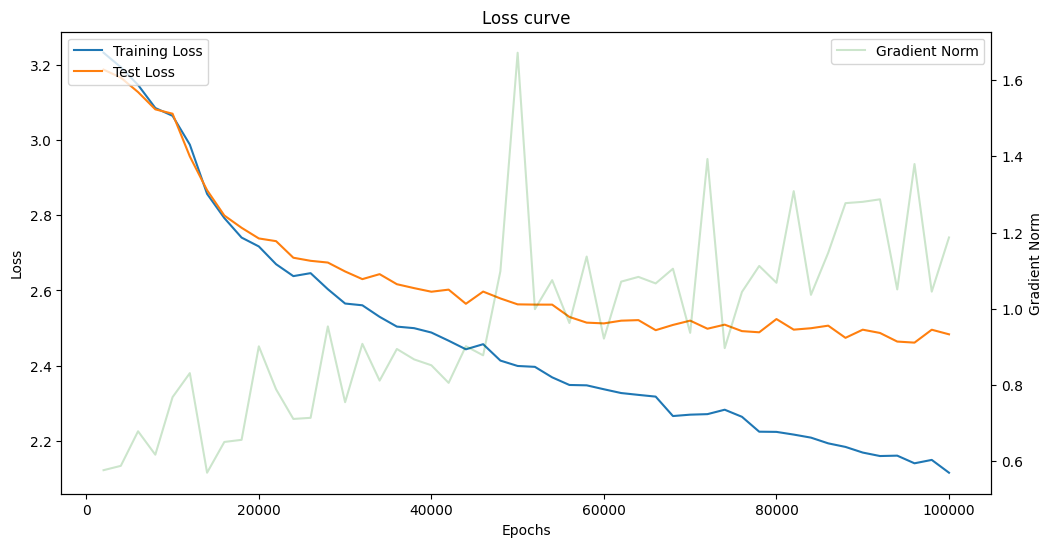

In [11]:
import matplotlib.pyplot as plt

### Visualize loss progression ###

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot training and test loss on the left y-axis
ax1.plot(epoch_count, train_loss_values, label='Training Loss')
ax1.plot(epoch_count, test_loss_values, label='Test Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.set_title('Loss curve')

# Plot gradient norm on the right y-axis
ax2 = ax1.twinx()
ax2.plot(epoch_count, gradients_norm, 'g', alpha=0.2, label='Gradient Norm')
ax2.set_ylabel('Gradient Norm')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.show()

In [1]:
print(model.translate('i did that slowly'))

NameError: name 'model' is not defined